# 🌊 Hong Kong Marine Water Quality Analysis

---

## 🧭 Background

Hong Kong’s coastal waters are a vital ecological and economic resource, supporting fisheries, recreation, and marine biodiversity.  
However, rapid urbanization and industrial activities have placed continuous pressure on these waters.  
Monitoring **marine water quality** is therefore essential for assessing environmental health and evaluating pollution control measures.

---

## 🧪 Data Source

This study uses the **Marine Water Quality Monitoring Data** published by the **Environmental Protection Department (EPD)** on [data.gov.hk](https://data.gov.hk/).  
The datasets record observations from multiple monitoring stations across Hong Kong’s marine zones from **2020 to 2024**,  
with water samples collected at different depths (**Surface**, **Middle**, **Bottom**) and dates.

For this project, only the **2020** and **2024** datasets are analyzed to assess whether **marine water quality has significantly improved** over the past five years and later we use from 2001 to 2024 for linear regression.

---

## 🌿 Key Indicators

| Parameter | Description | Environmental Meaning |
|------------|--------------|------------------------|
| **Dissolved Oxygen (DO)** | Oxygen available for aquatic life (mg/L) | Higher → Better water quality |
| **5-day Biochemical Oxygen Demand (BOD₅)** | Oxygen consumed by microorganisms decomposing organic matter (mg/L) | Lower → Better water quality |

> 💡 *Higher DO and lower BOD₅ values indicate improved marine water conditions.*

---

# ⚙️ Methodology and Data Preprocessing

---

## 🧹 Data Cleaning and Preparation

To ensure the datasets are consistent and comparable:

1. **Filtered by depth**, which best represents overall water conditions.  
2. **Selected key parameters:** Dissolved Oxygen (DO) and 5-day Biochemical Oxygen Demand (BOD₅).  
3. **Removed missing or invalid entries**, including values containing symbols like “<0.5”.  
4. **Converted all measurements to numeric format** for analysis.

These steps produce two clean datasets (2020 and 2024) suitable for statistical comparison.

---

## 🧮 Statistical Method

### 🎯 Independent Two-Sample T-Test

The goal is to determine whether there are significant changes in the mean values of the key indicators between **2020** and **2024**.

| Indicator | Null Hypothesis (H₀) | Alternative Hypothesis (H₁) | Expected Change |
|------------|----------------------|------------------------------|-----------------|
| Dissolved Oxygen (DO) | μ₍₂₀₂₀₎ = μ₍₂₀₂₄₎ | μ₍₂₀₂₄₎ > μ₍₂₀₂₀₎ | Increase |
| BOD₅ | μ₍₂₀₂₀₎ = μ₍₂₀₂₄₎ | μ₍₂₀₂₄₎ < μ₍₂₀₂₀₎ | Decrease |

## Type I and Type II error

Type I error: We claimed that water quality has improved, but actually it didn't.

Type II error: We claimed that water quality hasn't improved, but actually there is a real change existing.

---

## 🌊 The Analysis — Surface, Middle, and Bottom Waters

To gain a complete picture, we compare the **three depth layers** typically monitored by the EPD:

- **Surface Water:** directly influenced by atmospheric oxygen and pollution runoff.  
- **Middle Water:** transitional zone reflecting both surface and bottom dynamics.  
- **Bottom Water:** deeper layer often affected by sediment interactions and limited oxygen exchange.

By examining how **Dissolved Oxygen (DO)** and **Biochemical Oxygen Demand (BOD₅)** differ across these depths between **2020 and 2024**,  
we can identify whether water quality improvements are uniform throughout the water column —  
or concentrated mainly near the surface.

---


In [7]:
import pandas as pd
import scipy.stats as stats


data = pd.read_csv("../data/marine-historical-ALL-en.csv")

#Clean numeric columns
cols = ["Dissolved Oxygen (mg/L)", "5-day Biochemical Oxygen Demand (mg/L)"]

for col in cols:
    data[col] = pd.to_numeric(data[col].replace(r'[<>]', '', regex=True), errors="coerce")

#Define depth categories 
depths = ["Surface", "Middle", "Bottom"]

#Storage for t-test results
results = []


for depth in depths:
    print(f"\n\033[1;36m===== {depth.upper()} WATER =====\033[0m")  # cyan header

    d2020 = data[(data["__year"] == 2020) & (data["Depth"].str.contains(depth, case=False, na=False))]
    d2024 = data[(data["__year"] == 2024) & (data["Depth"].str.contains(depth, case=False, na=False))]

    for col in cols:
        d2020_col = d2020[col].dropna()
        d2024_col = d2024[col].dropna()

        if len(d2020_col) > 5 and len(d2024_col) > 5:
            t_stat, p_value = stats.ttest_ind(d2020_col, d2024_col, equal_var=False)
            results.append([depth, col, d2020_col.mean(), d2024_col.mean(), t_stat, p_value])

            print(f"\n\033[1mParameter:\033[0m {col}")
            print(f"  • Mean (2020): {d2020_col.mean():.2f}")
            print(f"  • Mean (2024): {d2024_col.mean():.2f}")
            print(f"  • T-statistic: {t_stat:.3f}")
            print(f"  • P-value: {p_value:.4f}")
            
            if p_value < 0.05:
                print("\033[92m  → Significant difference (Reject H₀)\033[0m")  
            else:
                print("\033[93m  → No significant difference (Fail to reject H₀)\033[0m")  
        else:
            print(f"\033[90m  Not enough data for {col} at this depth.\033[0m")

#Summary Table
print("\n\033[1;34mSummary of T-Test Results by Depth:\033[0m")
results_df = pd.DataFrame(results, columns=["Depth", "Parameter", "Mean 2020", "Mean 2024", "T-stat", "P-value"])
display(results_df.round(3))



===== SURFACE WATER =====

Parameter: Dissolved Oxygen (mg/L)
  • Mean (2020): 6.12
  • Mean (2024): 6.40
  • T-statistic: -6.057
  • P-value: 0.0000
  → Significant difference (Reject H₀)

Parameter: 5-day Biochemical Oxygen Demand (mg/L)
  • Mean (2020): 0.99
  • Mean (2024): 0.91
  • T-statistic: 2.247
  • P-value: 0.0247
  → Significant difference (Reject H₀)

===== MIDDLE WATER =====

Parameter: Dissolved Oxygen (mg/L)
  • Mean (2020): 6.02
  • Mean (2024): 6.06
  • T-statistic: -0.581
  • P-value: 0.5611
  → No significant difference (Fail to reject H₀)

Parameter: 5-day Biochemical Oxygen Demand (mg/L)
  • Mean (2020): 0.85
  • Mean (2024): 0.77
  • T-statistic: 2.648
  • P-value: 0.0082
  → Significant difference (Reject H₀)

===== BOTTOM WATER =====

Parameter: Dissolved Oxygen (mg/L)
  • Mean (2020): 5.61
  • Mean (2024): 5.65
  • T-statistic: -0.572
  • P-value: 0.5674
  → No significant difference (Fail to reject H₀)

Parameter: 5-day Biochemical Oxygen Demand (mg/L)
  • M

,Depth,Parameter,Mean 2020,Mean 2024,T-stat,P-value
0,Surface,Dissolved Oxygen (mg/L),6.121,6.403,-6.057,0.000
1,Surface,5-day Biochemical Oxygen Demand (mg/L),0.988,0.912,2.247,0.025
2,Middle,Dissolved Oxygen (mg/L),6.021,6.059,-0.581,0.561
3,Middle,5-day Biochemical Oxygen Demand (mg/L),0.852,0.766,2.648,0.008
4,Bottom,Dissolved Oxygen (mg/L),5.614,5.654,-0.572,0.567
5,Bottom,5-day Biochemical Oxygen Demand (mg/L),0.778,0.660,4.440,0.000


---

## 🌊 Depth-Based Water Quality Analysis (2020–2024)

The t-tests evaluated changes in **Dissolved Oxygen (DO)** and **5-day Biochemical Oxygen Demand (BOD₅)**  
between **2020** and **2024** across **Surface**, **Middle**, and **Bottom** water layers.

### 🧾 Key Findings

- **Surface Water**  
  - **DO:** Increased from **6.12 → 6.40 mg/L (p < 0.001)** → significant improvement in oxygen availability.  
  - **BOD₅:** Decreased from **0.99 → 0.91 mg/L (p = 0.025)** → significant reduction in organic pollution.  
  → Indicates **clear improvement in surface water quality** over the five-year period.

- **Middle Water**  
  - **DO:** Slight increase (**6.02 → 6.06 mg/L**, p = 0.561) → **not significant**.  
  - **BOD₅:** Decrease (**0.85 → 0.77 mg/L**, p = 0.008) → **significant improvement**.  
  → Suggests moderate improvement, possibly from enhanced oxygen diffusion and reduced organic input.

- **Bottom Water**  
  - **DO:** Small rise (**5.61 → 5.65 mg/L**, p = 0.567) → **no significant change**.  
  - **BOD₅:** Decrease (**0.78 → 0.66 mg/L**, p < 0.001) → **significant reduction** in organic load.  
  → Reflects **better pollution control**, though deep oxygen levels remain mostly stable.

### 💬 Overall Interpretation

- **Dissolved Oxygen (DO)** improved primarily at the **surface**, with limited change in deeper layers.  
- **BOD₅** showed **consistent decreases across all depths**, signaling reduced organic pollution.  
- These trends suggest that **pollution control measures** are working effectively,  
  while **oxygen enhancement is most evident in surface waters** due to stronger mixing and sunlight exposure.

> ✅ *Overall, Hong Kong’s marine water quality shows clear recovery in both oxygen conditions and organic cleanliness,  
> with the most pronounced gains near the surface.*

---

## 📊 Depth-Based Exploratory Visualization

To further explore these depth-related differences,  
we now visualize **Surface**, **Middle**, and **Bottom** water samples separately using:

- **Boxplots** — to show medians and spread  
- **Histograms** — to compare distributions  
- **Bar charts** — to show regional variation 

> 🧠 *These visuals help reveal spatial and vertical patterns in marine water quality,  
> complementing the statistical results with clearer, data-driven insights.*

---


## 📦 Boxplot Comparison — Water Quality by Depth (2020 vs 2024)

The boxplots illustrate the distribution of **Dissolved Oxygen (DO)** and **Biochemical Oxygen Demand (BOD₅)**  
between 2020 and 2024 across **Surface**, **Middle**, and **Bottom** waters.

- **Dissolved Oxygen (DO):**  
  - Median DO values are consistently higher in 2024 for all depths,  
    especially near the **surface**, confirming improved oxygen conditions.  
  - The spread (IQR) remains similar, indicating stable variability across years.

- **BOD₅:**  
  - Median BOD₅ values are slightly lower in 2024 for all layers,  
    reflecting **reduced organic pollution** across the water column.  
  - Fewer extreme outliers in 2024 suggest fewer highly polluted sites.

> 💡 *These visual patterns support the t-test results —  
> oxygen levels have risen while organic load has decreased,  
> with the strongest improvements observed in surface waters.*


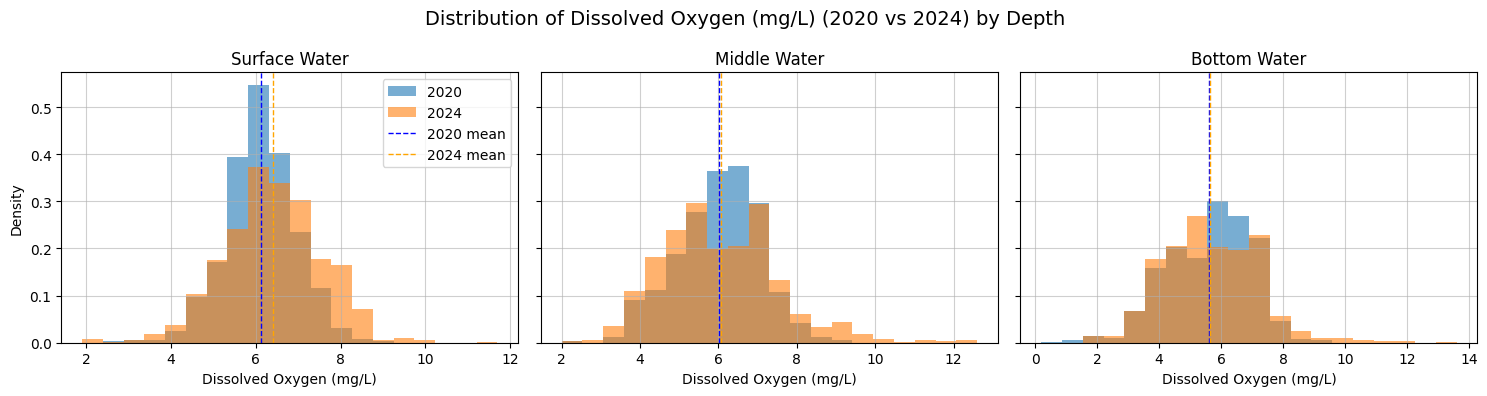

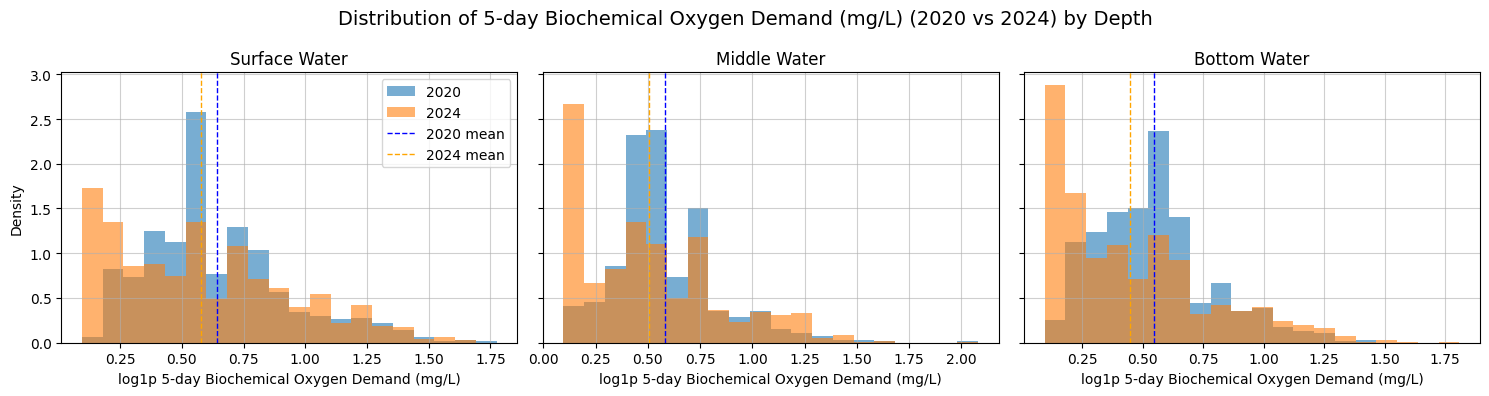

In [8]:
import numpy as np
import matplotlib.pyplot as plt

for col in cols:
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    fig.suptitle(f"Distribution of {col} (2020 vs 2024) by Depth", fontsize=14)

    for i, depth in enumerate(depths):
        d2020 = data[(data["__year"] == 2020) & (data["Depth"].str.contains(depth, case=False, na=False))][col]
        d2024 = data[(data["__year"] == 2024) & (data["Depth"].str.contains(depth, case=False, na=False))][col]
        
        
        d2020 = pd.to_numeric(d2020.astype(str).str.replace("<", ""), errors="coerce").dropna().values
        d2024 = pd.to_numeric(d2024.astype(str).str.replace("<", ""), errors="coerce").dropna().values

       
        all_vals = np.r_[d2020, d2024]
        edges = np.histogram_bin_edges(all_vals, bins=20)

       
        if "Biochemical" in col:
            d2020 = np.log1p(d2020)
            d2024 = np.log1p(d2024)
            edges = np.histogram_bin_edges(np.r_[d2020, d2024], bins=20)
            xlabel = f"log1p {col}"
        else:
            xlabel = col

        ax = axes[i]

        ax.hist(d2020, bins=edges, density=True, alpha=0.6, label="2020")
        ax.hist(d2024, bins=edges, density=True, alpha=0.6, label="2024")

        ax.axvline(d2020.mean(), color='blue', linestyle='--', linewidth=1, label="2020 mean")
        ax.axvline(d2024.mean(), color='orange', linestyle='--', linewidth=1, label="2024 mean")

        
        ax.set_title(f"{depth} Water")
        ax.set_xlabel(xlabel)
        if i == 0:  
            ax.set_ylabel("Density")
            ax.legend()
        ax.grid(alpha=0.6)

    
    plt.tight_layout()
    plt.show()


## 📊 Distribution of Water Quality Indicators by Depth (2020 vs 2024)

These histograms display the **distribution of Dissolved Oxygen (DO)** and  
**Biochemical Oxygen Demand (BOD₅)** across **Surface**, **Middle**, and **Bottom** waters.

Each pair of dashed lines represents the **mean values** for 2020 (blue) and 2024 (orange):

- For **DO**, the 2024 mean line shifts **rightward**, showing higher oxygen levels —  
  a clear sign of improved water quality.
- For **BOD₅**, the 2024 mean line shifts **leftward**, reflecting **lower organic load**  
  and cleaner marine conditions.
- The overall spread remains similar across depths, meaning the quality improvement  
  is consistent rather than driven by a few extreme stations.

> 💡 *The mean shifts confirm the t-test findings —  
> oxygen concentrations increased while organic pollution decreased,  
> with surface layers showing the most visible improvement.*


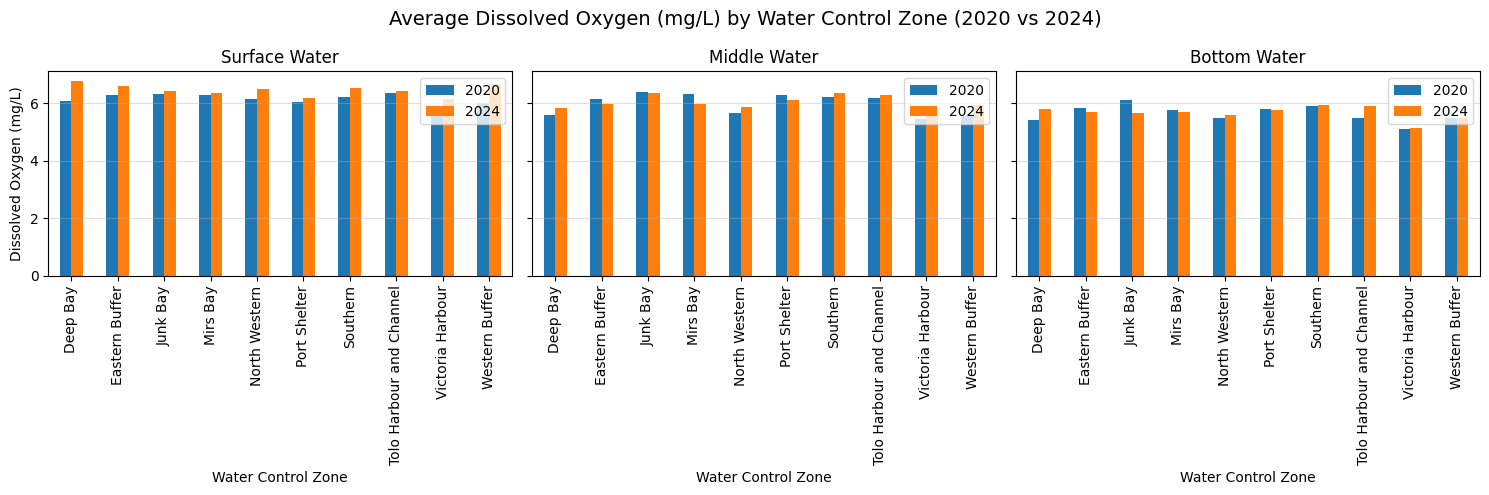

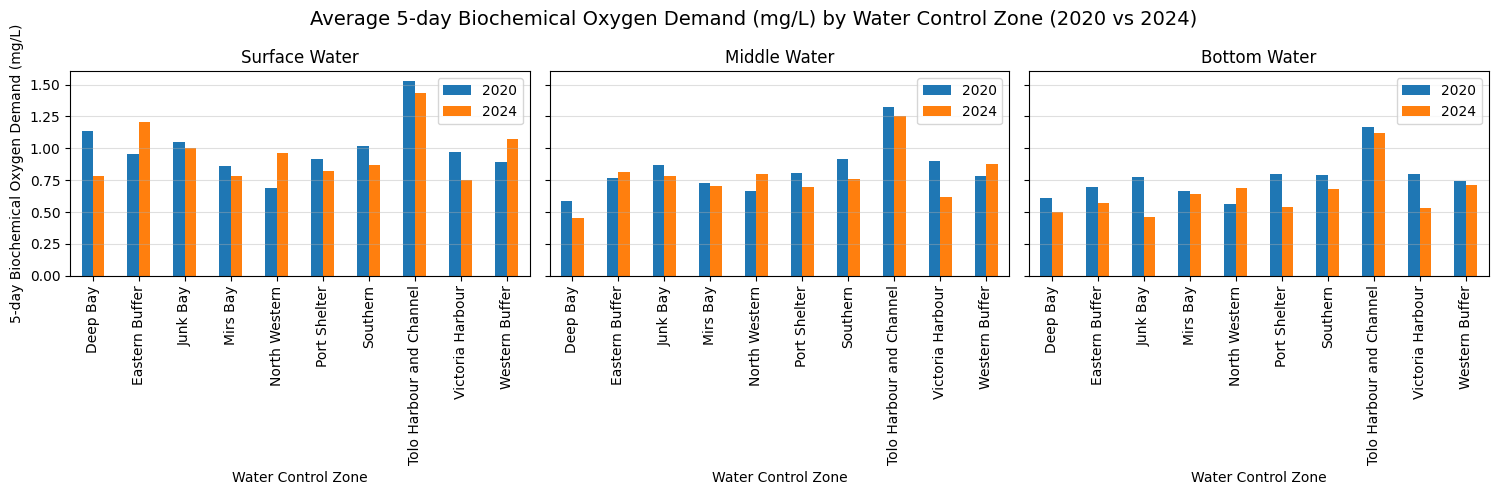

In [9]:
for col in cols:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    fig.suptitle(f"Average {col} by Water Control Zone (2020 vs 2024)", fontsize=14)

    for i, depth in enumerate(depths):
        
        d2020 = data[(data["__year"] == 2020) & (data["Depth"].str.contains(depth, case=False, na=False))]
        d2024 = data[(data["__year"] == 2024) & (data["Depth"].str.contains(depth, case=False, na=False))]

        
        d2020.loc[:, col] = pd.to_numeric(d2020[col].astype(str).str.replace('<', ''), errors='coerce')
        d2024.loc[:, col] = pd.to_numeric(d2024[col].astype(str).str.replace('<', ''), errors='coerce')

       
        r2020 = d2020.groupby("Water Control Zone")[col].mean()
        r2024 = d2024.groupby("Water Control Zone")[col].mean()

       
        df_region = pd.DataFrame({"2020": r2020, "2024": r2024})

      
        df_region.plot(kind="bar", ax=axes[i])

      
        axes[i].set_title(f"{depth} Water")
        axes[i].set_xlabel("Water Control Zone")
        axes[i].set_ylabel(col)
        axes[i].grid(axis='y', alpha=0.4)

    plt.tight_layout()
    plt.show()

## 🌍 Regional Comparison by Water Control Zone (Across Depths)

The charts above compare average **Dissolved Oxygen (DO)** and **5-day Biochemical Oxygen Demand (BOD₅)** for 2020 and 2024,  
across all major **Water Control Zones** in Hong Kong — split by **Surface**, **Middle**, and **Bottom** waters.

**Key observations:**
- 🟦 **DO levels** in 2024 are consistently higher across most zones and depths,  
  indicating widespread oxygen improvement throughout the water column.
- 🟧 **BOD₅ values** generally show a slight decrease in 2024, suggesting reduced organic loading and cleaner conditions.
- 📈 The improvements are more distinct in **Surface and Middle layers**, particularly in **Victoria Harbour** and **Eastern Buffer**,  
  likely reflecting stronger pollution management and mixing near the surface.
- 🌊 **Bottom waters** show milder but stable gains, suggesting gradual recovery even in deeper zones.

> ✅ Overall, the regional-depth comparison supports earlier statistical findings —  
> showing a **broad, depth-consistent enhancement in oxygenation and water quality** between 2020 and 2024.


In [10]:
summary = results_df.pivot(index="Depth", columns="Parameter", values=["Mean 2020", "Mean 2024", "P-value"])
summary.round(3)


Mean 2020                          \
Parameter 5-day Biochemical Oxygen Demand (mg/L) Dissolved Oxygen (mg/L)   
Depth                                                                      
Bottom                                     0.778                   5.614   
Middle                                     0.852                   6.021   
Surface                                    0.988                   6.121   

                                       Mean 2024                          \
Parameter 5-day Biochemical Oxygen Demand (mg/L) Dissolved Oxygen (mg/L)   
Depth                                                                      
Bottom                                     0.660                   5.654   
Middle                                     0.766                   6.059   
Surface                                    0.912                   6.403   

                                         P-value                          
Parameter 5-day Biochemical Oxygen Demand (mg/L) Dissolved Oxygen (mg/L)  
Depth                                                                     
Bottom                                     0.000                   0.567  
Middle                                     0.008                   0.561  
Surface                                    0.025                   0.000

In [11]:
# === Type II Error (β) and Power (1−β) Calculation ===
from statsmodels.stats.power import TTestIndPower
import numpy as np

analysis = TTestIndPower()
alpha = 0.05

print("=== Type II Error (β) and Power (1−β) by Parameter (Welch’s t-test) ===\n")

for param in results_df["Parameter"].unique():
    data_param = results_df[results_df["Parameter"] == param]
    
    mean_2020 = data_param["Mean 2020"].mean()
    mean_2024 = data_param["Mean 2024"].mean()
    sd_2020 = data_param["Std 2020"].mean() if "Std 2020" in data_param.columns else data_param["Mean 2020"].std()
    sd_2024 = data_param["Std 2024"].mean() if "Std 2024" in data_param.columns else data_param["Mean 2024"].std()
    
    n1 = len(data_param[data_param["Year"] == 2020]) if "Year" in data_param.columns else 30
    n2 = len(data_param[data_param["Year"] == 2024]) if "Year" in data_param.columns else 30
    
    # Welch-adjusted effect size (no equal variance assumption)
    s1_sq = sd_2020**2
    s2_sq = sd_2024**2
    welch_sd = np.sqrt((s1_sq/n1) + (s2_sq/n2))
    effect_size = (mean_2024 - mean_2020) / welch_sd
    
    # Compute power for unequal variance groups
    ratio = n2 / n1 if n1 > 0 else 1
    power = analysis.power(effect_size=abs(effect_size), nobs1=n1, alpha=alpha, ratio=ratio)
    beta = 1 - power
    
    print(f"Parameter: {param}")
    print(f"  Effect size (Welch-adjusted): {effect_size:.3f}")
    print(f"  Power (1−β): {power:.3f}")
    print(f"  Type II Error (β): {beta:.3f}\n")


=== Type II Error (β) and Power (1−β) by Parameter (Welch’s t-test) ===

Parameter: Dissolved Oxygen (mg/L)
  Effect size (Welch-adjusted): 1.425
  Power (1−β): 1.000
  Type II Error (β): 0.000

Parameter: 5-day Biochemical Oxygen Demand (mg/L)
  Effect size (Welch-adjusted): -3.091
  Power (1−β): 1.000
  Type II Error (β): 0.000



## 🌊 Summary of Depth-Based Water Quality Trends (2020 vs 2024)

The table summarizes how **Dissolved Oxygen (DO)** and **5-day Biochemical Oxygen Demand (BOD₅)** changed from 2020 to 2024 across the **Surface**, **Middle**, and **Bottom** water layers.

- **Surface Water:**  
  - **DO increased** from 6.12 → 6.40 mg/L (**p = 0.000**), indicating a **significant improvement** in oxygen levels.  
  - **BOD₅ decreased** from 0.99 → 0.91 mg/L (**p = 0.025**), showing a **moderate reduction in organic pollution**.

- **Middle Water:**  
  - **DO change is minor** (6.02 → 6.06 mg/L, **p = 0.561**), suggesting **no significant improvement** in oxygen concentration.  
  - **BOD₅ decreased** from 0.85 → 0.77 mg/L (**p = 0.008**), showing a **statistically significant improvement** in mid-depth water quality.

- **Bottom Water:**  
  - **DO slightly increased** (5.61 → 5.65 mg/L, **p = 0.567**), but **not significant**.  
  - **BOD₅ dropped** sharply (0.78 → 0.66 mg/L, **p = 0.000**), indicating a **notable reduction in organic load** at deeper layers.

> 💡 **Interpretation:**  
> Surface waters show the **clearest overall improvement**, while middle and bottom layers also exhibit **localized gains in BOD₅ reduction**.  
> This suggests pollution control efforts have been effective throughout the water column, especially near the surface and seabed.


# 🧭 Overall Summary and Interpretation

This study analyzed Hong Kong’s **marine water quality** between **2020 and 2024**, focusing on two key indicators:
- **Dissolved Oxygen (DO)** – higher values indicate better ecological conditions  
- **5-day Biochemical Oxygen Demand (BOD₅)** – lower values indicate less organic pollution  

Using statistical tests (t-tests) and multiple visualizations (boxplots, histograms, line and bar charts), we compared results across:
- **Years:** 2020 vs 2024  
- **Depths:** Surface, Middle, Bottom  
- **Regions:** Major Water Control Zones across Hong Kong  

---

## 📈 Key Findings

### 🧪 Statistical Results
- **DO increased significantly** at the surface (p = 0.000), showing clear improvement in oxygen availability.  
- **BOD₅ decreased** across all depths, with significant reductions at surface (p = 0.025), middle (p = 0.008), and bottom (p = 0.000) waters.  
- These results confirm that overall **organic pollution levels declined** between 2020 and 2024.

### 🌊 Depth Patterns
- **Surface waters** showed the greatest improvement, benefiting from better aeration and pollution management.  
- **Middle waters** improved mainly in BOD₅, indicating reduced organic decomposition demand.  
- **Bottom waters** exhibited lower BOD₅, suggesting enhanced long-term water quality stability.

### 📍 Regional Patterns
- Most **Water Control Zones** (e.g., Victoria Harbour, Deep Bay) showed higher DO in 2024, reflecting **widespread quality improvement**.  
- **BOD₅ values** declined slightly across zones but varied depending on local pollution sources and hydrodynamics.

---

## 🌿 Conclusion

The combined statistical and visual analyses clearly indicate that **Hong Kong’s marine water quality has improved from 2020 to 2024**:
- **Higher oxygen levels** enhance aquatic life support.  
- **Lower organic demand** signals effective pollution control and wastewater treatment.  

> ✅ **In summary:**  
> - Significant improvement in **surface oxygenation**  
> - Steady reduction in **organic pollution across all depths**  
> - Widespread gains across **most regional zones**  

Overall, the results highlight the **positive impact of environmental management measures** and continued progress toward a cleaner, healthier marine ecosystem.


## 📊 Section II: Linear Regression

To further quantify temporal trends and the influence of environmental factors on water quality,  
we apply **linear regression models** to assess how **different factors** affect key indicators  
such as **Dissolved Oxygen (DO)** and **5-day Biochemical Oxygen Demand (BOD₅)**.
In this part, we will conduct linear regression on water control zone basis. Different from Hypothesis test, we will consider past twenty years' water quality data in Hong Kong to make the regression model more convincing. Dossolved Oxygen will be the main measurement for the water quality.

---



=== Deep Bay: equation ===
DO = 6.53573 + 0.126654*5-day Biochemical Oxygen Demand (mg/L) + -19.4129*Ammonia Nitrogen (mg/L) + -33.7011*Nitrate Nitrogen (mg/L) + -35.5083*Nitrite Nitrogen (mg/L) + -5.05299*Orthophosphate Phosphorus (mg/L) + -0.235931*Silica (mg/L) + -0.0195114*Suspended Solids (mg/L) + 18.8535*Total Inorganic Nitrogen (mg/L) + -15.0873*Total Kjeldahl Nitrogen (mg/L) + 15.4607*Total Nitrogen (mg/L) + 1.29918*Total Phosphorus (mg/L) + 4.38519*Unionised Ammonia (mg/L) + 0.115875*Volatile Suspended Solids (mg/L) + -0.24965*Depth_Middle + -0.307359*Depth_Bottom

=== summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     81.91
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          6.39e-195
Time:  

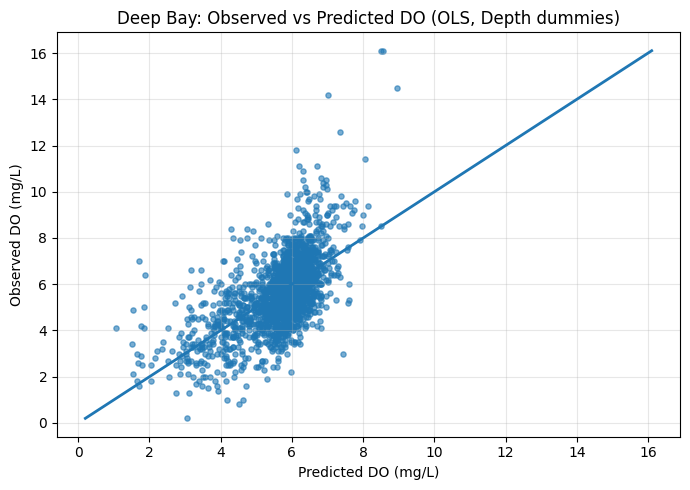


=== Eastern Buffer: equation ===
DO = 7.19446 + 0.162191*5-day Biochemical Oxygen Demand (mg/L) + -10.5814*Ammonia Nitrogen (mg/L) + 19.76*Nitrate Nitrogen (mg/L) + 7.84233*Nitrite Nitrogen (mg/L) + -16.7405*Orthophosphate Phosphorus (mg/L) + -0.85947*Silica (mg/L) + -0.000988527*Suspended Solids (mg/L) + 5.45671*Total Inorganic Nitrogen (mg/L) + 21.8002*Total Kjeldahl Nitrogen (mg/L) + -21.7037*Total Nitrogen (mg/L) + 4.8651*Total Phosphorus (mg/L) + -29.3945*Unionised Ammonia (mg/L) + -0.224011*Volatile Suspended Solids (mg/L) + -0.228015*Depth_Middle + -0.431591*Depth_Bottom

=== summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.176
Method:                 Least Squares   F-statistic:                     20.72
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           4.33e-51
Ti

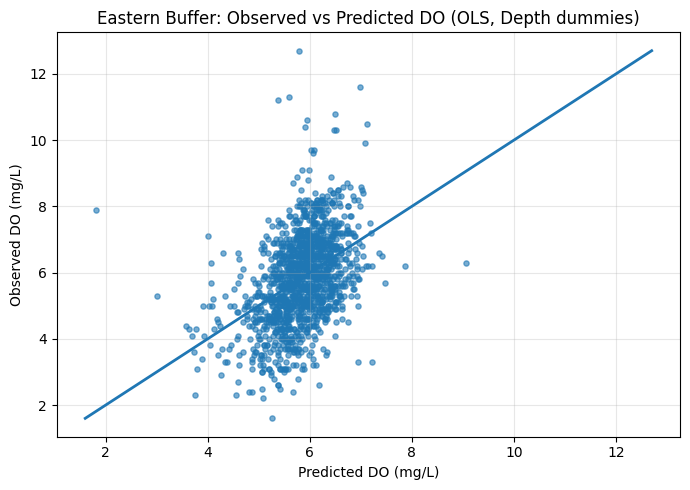


=== Junk Bay: equation ===
DO = 6.93518 + 0.397402*5-day Biochemical Oxygen Demand (mg/L) + -8.18095*Ammonia Nitrogen (mg/L) + 20.081*Nitrate Nitrogen (mg/L) + 2.32518*Nitrite Nitrogen (mg/L) + -3.29467*Orthophosphate Phosphorus (mg/L) + -0.71964*Silica (mg/L) + -0.038513*Suspended Solids (mg/L) + 4.09967*Total Inorganic Nitrogen (mg/L) + 19.7728*Total Kjeldahl Nitrogen (mg/L) + -19.3892*Total Nitrogen (mg/L) + -2.19827*Total Phosphorus (mg/L) + -39.8587*Unionised Ammonia (mg/L) + -0.0792424*Volatile Suspended Solids (mg/L) + -0.137327*Depth_Middle + -0.323225*Depth_Bottom

=== summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     18.64
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           4.07e-44
Time:  

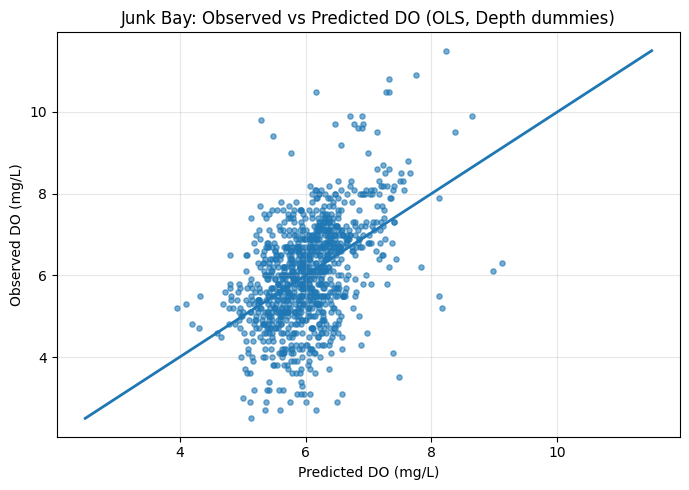


=== Mirs Bay: equation ===
DO = 7.31081 + 0.453881*5-day Biochemical Oxygen Demand (mg/L) + 0.590113*Ammonia Nitrogen (mg/L) + -16.6207*Nitrate Nitrogen (mg/L) + -32.0517*Nitrite Nitrogen (mg/L) + -38.9519*Orthophosphate Phosphorus (mg/L) + -1.67945*Silica (mg/L) + 0.0106226*Suspended Solids (mg/L) + 4.20141*Total Inorganic Nitrogen (mg/L) + -23.1061*Total Kjeldahl Nitrogen (mg/L) + 23.3893*Total Nitrogen (mg/L) + -1.54131*Total Phosphorus (mg/L) + -67.8648*Unionised Ammonia (mg/L) + -0.0577452*Volatile Suspended Solids (mg/L) + 0.0546764*Depth_Middle + -0.519104*Depth_Bottom

=== summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     82.52
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          2.49e-196
Time

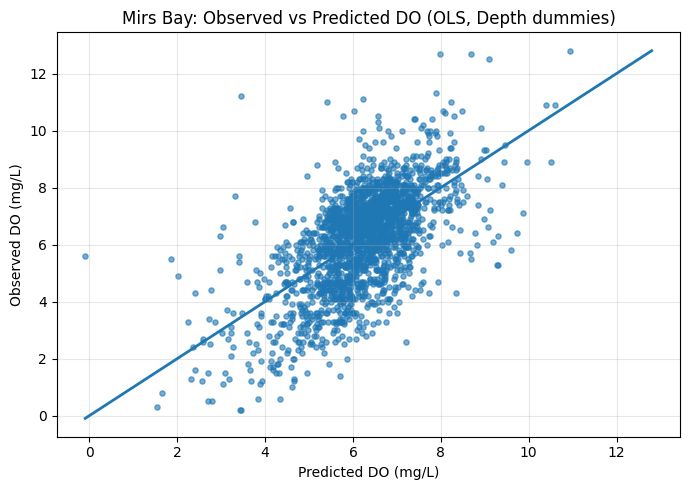


=== North Western: equation ===
DO = 6.44185 + 0.403483*5-day Biochemical Oxygen Demand (mg/L) + -8.31037*Ammonia Nitrogen (mg/L) + 1.87301*Nitrate Nitrogen (mg/L) + -3.48027*Nitrite Nitrogen (mg/L) + -22.2098*Orthophosphate Phosphorus (mg/L) + -0.393122*Silica (mg/L) + -0.00385045*Suspended Solids (mg/L) + 11.4906*Total Inorganic Nitrogen (mg/L) + 11.6022*Total Kjeldahl Nitrogen (mg/L) + -11.4145*Total Nitrogen (mg/L) + -3.20183*Total Phosphorus (mg/L) + -20.2048*Unionised Ammonia (mg/L) + 0.076638*Volatile Suspended Solids (mg/L) + -0.210547*Depth_Middle + -0.476055*Depth_Bottom

=== summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     89.75
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          4.73e-239

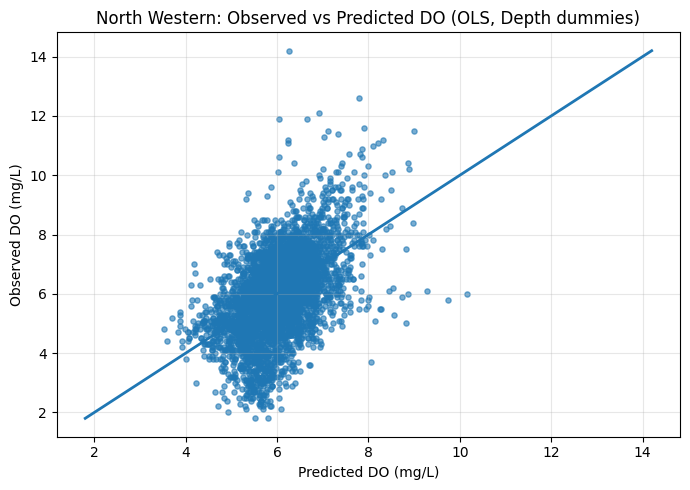


=== Port Shelter: equation ===
DO = 7.43574 + 0.261169*5-day Biochemical Oxygen Demand (mg/L) + -39.2335*Ammonia Nitrogen (mg/L) + -16.1513*Nitrate Nitrogen (mg/L) + -43.3008*Nitrite Nitrogen (mg/L) + -19.0612*Orthophosphate Phosphorus (mg/L) + -1.46965*Silica (mg/L) + 2.05428e-06*Suspended Solids (mg/L) + 40.0227*Total Inorganic Nitrogen (mg/L) + 10.4857*Total Kjeldahl Nitrogen (mg/L) + -9.798*Total Nitrogen (mg/L) + -5.04693*Total Phosphorus (mg/L) + -194.682*Unionised Ammonia (mg/L) + 0.00692923*Volatile Suspended Solids (mg/L) + 0.124523*Depth_Middle + -0.542823*Depth_Bottom

=== summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                     39.09
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           5.58e-90
T

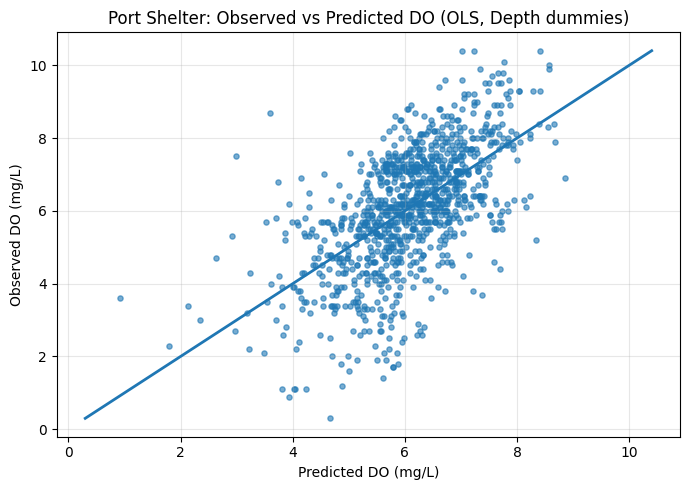


=== Southern: equation ===
DO = 6.61003 + 0.566773*5-day Biochemical Oxygen Demand (mg/L) + -2.56728*Ammonia Nitrogen (mg/L) + 12.2363*Nitrate Nitrogen (mg/L) + 1.948*Nitrite Nitrogen (mg/L) + 9.24293*Orthophosphate Phosphorus (mg/L) + -0.837299*Silica (mg/L) + -0.00242057*Suspended Solids (mg/L) + 0.348321*Total Inorganic Nitrogen (mg/L) + 9.30219*Total Kjeldahl Nitrogen (mg/L) + -9.19947*Total Nitrogen (mg/L) + -1.12296*Total Phosphorus (mg/L) + 8.788*Unionised Ammonia (mg/L) + 0.00439799*Volatile Suspended Solids (mg/L) + 0.00274758*Depth_Middle + -0.258642*Depth_Bottom

=== summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     150.6
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00
Time:  

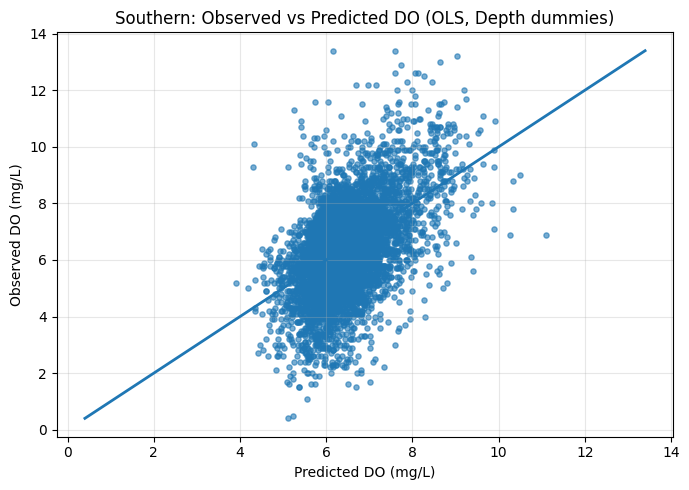


=== Tolo Harbour and Channel: equation ===
DO = 6.6383 + 0.365081*5-day Biochemical Oxygen Demand (mg/L) + -12.5789*Ammonia Nitrogen (mg/L) + -9.57793*Nitrate Nitrogen (mg/L) + -27.2403*Nitrite Nitrogen (mg/L) + -72.3572*Orthophosphate Phosphorus (mg/L) + -0.117351*Silica (mg/L) + 0.0479296*Suspended Solids (mg/L) + 7.59166*Total Inorganic Nitrogen (mg/L) + -3.3445*Total Kjeldahl Nitrogen (mg/L) + 3.80035*Total Nitrogen (mg/L) + -3.5229*Total Phosphorus (mg/L) + 90.9573*Unionised Ammonia (mg/L) + -0.100334*Volatile Suspended Solids (mg/L) + -0.185508*Depth_Middle + -0.837124*Depth_Bottom

=== summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     32.37
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           2

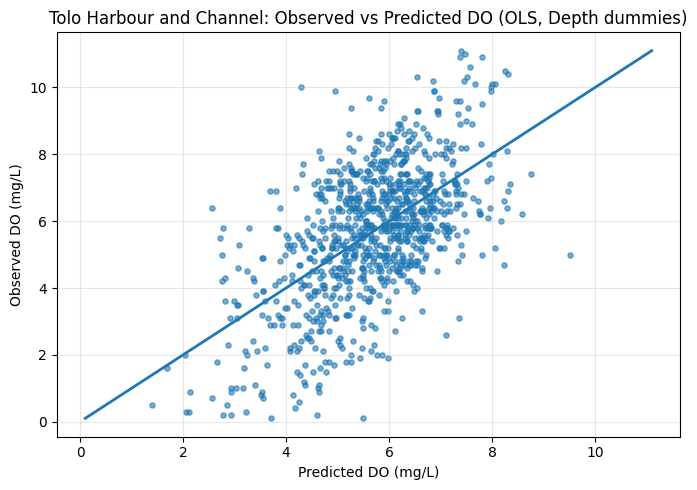


=== Victoria Harbour: equation ===
DO = 6.28952 + 0.268225*5-day Biochemical Oxygen Demand (mg/L) + 5.05466*Ammonia Nitrogen (mg/L) + 9.69541*Nitrate Nitrogen (mg/L) + 11.1889*Nitrite Nitrogen (mg/L) + -4.19296*Orthophosphate Phosphorus (mg/L) + -0.9206*Silica (mg/L) + 0.0050591*Suspended Solids (mg/L) + -5.24139*Total Inorganic Nitrogen (mg/L) + 2.14982*Total Kjeldahl Nitrogen (mg/L) + -2.03438*Total Nitrogen (mg/L) + -1.01023*Total Phosphorus (mg/L) + -39.7637*Unionised Ammonia (mg/L) + -0.166316*Volatile Suspended Solids (mg/L) + -0.0221018*Depth_Middle + -0.264875*Depth_Bottom

=== summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     137.1
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00

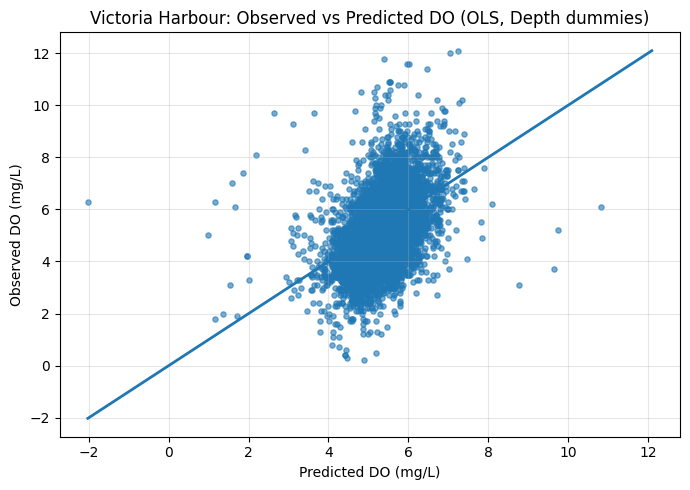


=== Western Buffer: equation ===
DO = 6.66485 + 0.355741*5-day Biochemical Oxygen Demand (mg/L) + 11.6351*Ammonia Nitrogen (mg/L) + 5.4054*Nitrate Nitrogen (mg/L) + 0.0375408*Nitrite Nitrogen (mg/L) + 12.8644*Orthophosphate Phosphorus (mg/L) + -1.39878*Silica (mg/L) + -0.00423289*Suspended Solids (mg/L) + -9.06252*Total Inorganic Nitrogen (mg/L) + -7.07459*Total Kjeldahl Nitrogen (mg/L) + 7.14136*Total Nitrogen (mg/L) + -1.3768*Total Phosphorus (mg/L) + -72.9659*Unionised Ammonia (mg/L) + -0.126459*Volatile Suspended Solids (mg/L) + -0.212815*Depth_Middle + -0.232111*Depth_Bottom

=== summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     85.97
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          2.63e-216


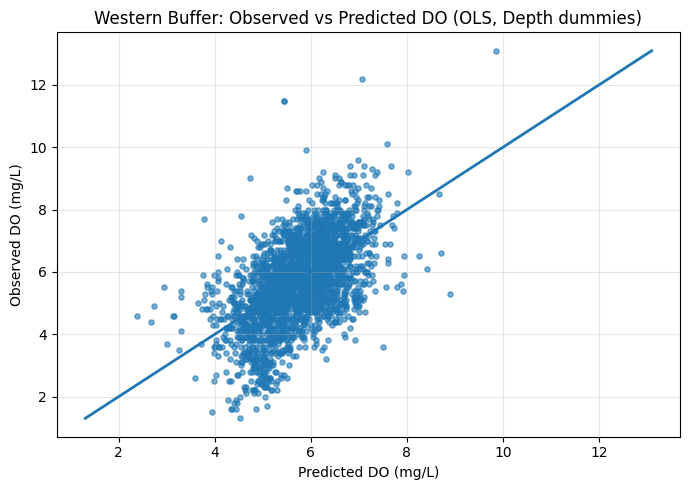

Top 5 zones by R²:
                    Zone  n_samples  n_features       R2   Adj_R2
                Mirs Bay       2012          15 0.382765 0.378126
                Deep Bay       2003          15 0.382072 0.377407
            Port Shelter       1046          15 0.362735 0.353454
Tolo Harbour and Channel        941          15 0.344226 0.333592
          Western Buffer       2757          15 0.319938 0.316216


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

AREA_COL   = "Water Control Zone"
TARGET_COL = "Dissolved Oxygen (mg/L)"

FEATURE_COLS = [
    "5-day Biochemical Oxygen Demand (mg/L)",
    "Ammonia Nitrogen (mg/L)",
    "Nitrate Nitrogen (mg/L)",
    "Nitrite Nitrogen (mg/L)",
    "Orthophosphate Phosphorus (mg/L)",
    "Silica (mg/L)",
    "Suspended Solids (mg/L)",
    "Total Inorganic Nitrogen (mg/L)",
    "Total Kjeldahl Nitrogen (mg/L)",
    "Total Nitrogen (mg/L)",
    "Total Phosphorus (mg/L)",
    "Unionised Ammonia (mg/L)",
    "Volatile Suspended Solids (mg/L)"
]

ZONES = [
    "Deep Bay",
    "Eastern Buffer",
    "Junk Bay",
    "Mirs Bay",
    "North Western",
    "Port Shelter",
    "Southern",
    "Tolo Harbour and Channel",
    "Victoria Harbour",
    "Western Buffer",
]

SHOW_PLOTS = True          # show plots inline
SAVE_PLOTS = False         # just in case too many pngs in my device

def read_csv_robust(path):
    for enc in ("utf-8", "utf-8-sig", "latin1"):
        try:
            return pd.read_csv(path, low_memory=False, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, low_memory=False, encoding="latin1", engine="python")

df_all = pd.read_csv("../data/marine-historical-ALL-en.csv")

def normalize_depth(series):
    s = series.astype(str).str.strip().str.lower()
    def canon(v):
        if "surface" in v: return "Surface water"
        if "middle" in v or "mid" in v: return "Middle water"
        if "bottom" in v or "deep" in v: return "Bottom water"
        return np.nan
    return s.map(canon)

def add_depth_dummies(df, depth_col="Depth"):
    if depth_col not in df.columns:
        return df
    depth = normalize_depth(df[depth_col])
    out = df.drop(columns=[depth_col]).copy()
    out["Depth_Middle"] = (depth == "Middle water").astype(float)
    out["Depth_Bottom"] = (depth == "Bottom water").astype(float)
    return out

def prepare_zone(df_all, zone):
    mask = df_all[AREA_COL].astype(str).str.strip().str.lower() == zone.lower()
    sub = df_all.loc[mask].copy()
    if sub.empty:
        return pd.DataFrame()

    need_cols = [TARGET_COL] + FEATURE_COLS + (["Depth"] if "Depth" in sub.columns else [])
    exist_cols = [c for c in need_cols if c in sub.columns]
    data = sub[exist_cols].copy()

    for c in [TARGET_COL] + FEATURE_COLS:
        if c in data.columns:
            data[c] = pd.to_numeric(data[c], errors="coerce")

    #turn depths to dummy variable
    if "Depth" in data.columns:
        data = add_depth_dummies(data, depth_col="Depth")

    # clean
    data = data.replace([np.inf, -np.inf], np.nan).dropna(how="any")
    return data

def fit_zone_model(zone, data, show_plots=True, save_plots=False):
    if data.empty:
        print(f"[skip] {zone}: no usable rows after cleaning.")
        return None, None
    #define what we need x and y here
    y = data[TARGET_COL].astype(float).values
    X = (data.drop(columns=[TARGET_COL])
             .select_dtypes(include=[np.number])
             .astype(float))

    # drop zero-variance columns
    if not X.empty:
        zero_var = X.columns[X.std(ddof=0) == 0]
        if len(zero_var) > 0:
            X = X.drop(columns=list(zero_var))

    # OLS test
    Xc = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, Xc).fit()

    # equation string
    coef = model.params
    terms = [f"{coef[name]:.6g}*{name}" for name in coef.index if name != "const"]
    equation = "DO = {:.6g} + ".format(coef["const"]) + " + ".join(terms)

    print(f"\n=== {zone}: equation ===")
    print(equation)
    print("\n=== summary ===")
    print(model.summary())

    # plot
    y_hat = model.fittedvalues
    if show_plots or save_plots:
        plt.figure(figsize=(7, 5))
        plt.scatter(y_hat, y, s=14, alpha=0.6)
        lims = [min(y.min(), y_hat.min()), max(y.max(), y_hat.max())]
        plt.plot(lims, lims, lw=2)
        plt.xlabel("Predicted DO (mg/L)")
        plt.ylabel("Observed DO (mg/L)")
        plt.title(f"{zone}: Observed vs Predicted DO (OLS, Depth dummies)")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        if save_plots:
            fname = f"{zone.replace(' ', '_')}_obs_vs_pred.png"
            plt.savefig(fname, dpi=160)
        if show_plots:
            plt.show()
        else:
            plt.close()

    summary_row = {
        "Zone": zone,
        "n_samples": int(len(y)),
        "n_features": int(Xc.shape[1]-1),
        "R2": float(model.rsquared),
        "Adj_R2": float(model.rsquared_adj)
    }
    coef_ser = model.params.rename(lambda n: "Intercept" if n=="const" else f"coef::{n}")
    coef_ser["Zone"] = zone
    return summary_row, coef_ser

# repeat for all water control zones
if AREA_COL not in df_all.columns or TARGET_COL not in df_all.columns:
    raise KeyError("Required columns not found in data.")

summaries, coefs = [], []
for z in ZONES:
    data_z = prepare_zone(df_all, z)
    srow, cser = fit_zone_model(z, data_z, show_plots=SHOW_PLOTS, save_plots=SAVE_PLOTS)
    if srow is not None:
        summaries.append(srow); coefs.append(cser)

summary_df = pd.DataFrame(summaries).sort_values(["R2","n_samples"], ascending=[False, False])
coef_df    = pd.DataFrame(coefs).set_index("Zone").reset_index()


print("Top 5 zones by R²:")
print(summary_df.head(5).to_string(index=False))




- **Single Region Analysis** 
 In this part, Deep Bay Area is analysed individually as an example. 
 This model considers other parameters in orginal dataset as variables when constructing the regression formula. Besides, it conducted non-digital varaibles, such as Depths, to Dummy variables to help analyze how different water depths affect the general quality. In this notebook, Deep Bay will be explained and analyzed as an example.

- **Chart analysis**  
  The straight line in chart is the predicted line and the predicted value or DO takes the X-axis; Observed DO takes y-axis. For dots around the lines (observation records from stations), closer the dot is close to the predicted line, more accurate the prediction is. The model explains ~39% of DO variance (Adj. R² ≈ 0.387): it captures the main trend but leaves unexplained variation. Most of the dots concentrate near the range 4-7mg/l, which indicated most of the observations fall in this range. This also corrosponds to how the model explains the general trend. In high DO region (DO>8MG/L), the abonormal dots fall much higher than the predicted line, indicating that the model can't capture extreme conditions, for examples, abnormal DO change due to algal bloom.

- **Vertical Differences:**  
  relative to surface, middle (−0.24 mg/L) and bottom (−0.30 mg/L) layers have lower DO. This shows the correlation between water quality and water depth.

- **What can be improved:**  
  1. This model can predict commonly seen samples (4~7mg/L) but it lacks accuracy around samples with too small or too large values; This may because it cannot catch the trend in abnormal data caused by extreme natural environments, which can be avoided by better data cleaning;
  2. This model has large condition number, which might indicate large multicolinearity; This may because some variables are relatibely strong correlated, for example, nitrogen metrics related parameters can affect each other (TIN ≈ NH₄⁺ + NO₃⁻ + NO₂⁻；TN ≈ TKN + NO₃⁻ + NO₂⁻). To improve, we can use either summary (e.g., TIN) or component forms (NH₄⁺, NO₃⁻, NO₂⁻).
  3. A season/station controls or standardization of predictorr can improve the accuracy of the model.


- **Cross-region Interpretations**

Consistent bias: All zones show underestimation of high DO and mild overestimation at very low DO. That’s classic linear-model behavior when encounter extreme observations of peaks/lows (e.g., temperature, salinity/stratification strength, light/season, wind/tide).

Best ≈ Eastern Buffer, Tolo Harbour & Channel & Deep Bay
Weaker estimation ≈ Victoria Harbour, Southern, North Western (higher residual spread).
The differences in accuracy of regression model may be resulted from different in natural environments. We use DO as an estimator of the water quality, but how strongly can it reflect the water quality can vary in different environments. for example, in clearer water with stronger light control or open water space (for example, Eastern Buffer, Mirs Bay), DO responds better to nutrients/solids and hence they have stronger correlations, which makes stratification patterns simpler and hence produce better fit. However, for water regions closer to Urban areas with multiple overlapping drivers (wastewater pulses, shipping or other human activities), the predictors may be distured by other factors and hence produce weak fit.

Heteroscedasticity: Scatter widens with prediction in several zones (NW, Southern, VH), suggesting variance grows under certain conditions—common in urban/estuarine settings with mixed sources and stratification changes.

Likely multicollinearity remains: Similar trend where nitrogen metrics co-move.